# Canonical Data Visualization

This notebook reads the five canonical datasets and builds the Chapter 4 figures in their required order. All reader-facing chart text is in English.

The first figure is the primary longitudinal result: **Dataset A → Longitudinal Architectural Trajectory**.

In [18]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 180)

def locate_analysis_dir(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "data" / "clean" / "datasetA.csv").exists():
            return candidate
    raise FileNotFoundError("Could not locate reports/analysis from the current working directory.")

ANALYSIS_DIR = locate_analysis_dir(Path.cwd().resolve())
CLEAN_DIR = ANALYSIS_DIR / "data" / "clean"
FIGURE_DIR = ANALYSIS_DIR / "figures" / "chapter4"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "legend.frameon": False,
})

ANALYSIS_DIR, FIGURE_DIR

(PosixPath('/Users/luowei/project/ai-architecture-integrity-study/reports/analysis'),
 PosixPath('/Users/luowei/project/ai-architecture-integrity-study/reports/analysis/figures/chapter4'))

## 1. Read the five canonical datasets

All figures in this notebook must use these clean analysis datasets rather than presentation tables or raw experiment artifacts.

In [19]:
dataset_a = pd.read_csv(CLEAN_DIR / "datasetA.csv")
dataset_b = pd.read_csv(CLEAN_DIR / "datasetB.csv")
dataset_c = pd.read_csv(CLEAN_DIR / "datasetC.csv")
dataset_d = pd.read_csv(CLEAN_DIR / "datasetD.csv")
dataset_e = pd.read_csv(CLEAN_DIR / "datasetE.csv")

datasets = {
    "Dataset A — Checkpoint Summary": dataset_a,
    "Dataset B — Concern × Checkpoint": dataset_b,
    "Dataset C — Metric Observations": dataset_c,
    "Dataset D — File Findings": dataset_d,
    "Dataset E — T4 Self-Assessment + Efficiency": dataset_e,
}

dataset_manifest = pd.DataFrame([
    {"dataset": name, "rows": len(frame), "columns": len(frame.columns)}
    for name, frame in datasets.items()
])
display(dataset_manifest)

for name, frame in datasets.items():
    print(name)
    display(frame.head(3))

,dataset,rows,columns
0,Dataset A — Checkpoint Summary,12,19
1,Dataset B — Concern × Checkpoint,228,16
2,Dataset C — Metric Observations,228,26
3,Dataset D — File Findings,58,13
4,Dataset E — T4 Self-Assessment + Efficiency,4,18


Dataset A — Checkpoint Summary


,evaluation_id,condition,session_id,agent,strategy,task,task_order,execution_status,functional_acceptance,functional_test_cases_total,functional_test_cases_passed,functional_test_cases_failed,absolute_finding_count,task_local_introduced_findings,task_local_resolved_findings,task_local_net_change,baseline_relative_introduced_findings,baseline_relative_resolved_findings,baseline_relative_net_change
0,session_20260817_130253/T1,Claude Minimal,session_20260817_130253,claude,minimal,T1,1,completed,pass,16,16,0,16,11,0,11,11,0,11
1,session_20260817_130253/T2,Claude Minimal,session_20260817_130253,claude,minimal,T2,2,completed,pass,33,33,0,16,9,9,0,12,1,11
2,session_20260817_130253/T3,Claude Minimal,session_20260817_130253,claude,minimal,T3,3,completed,fail,69,68,1,13,2,5,-3,9,1,8


Dataset B — Concern × Checkpoint


,evaluation_id,condition,session_id,agent,strategy,task,task_order,concern,layer,absolute_finding_count,task_local_introduced_findings,task_local_resolved_findings,task_local_net_change,baseline_relative_introduced_findings,baseline_relative_resolved_findings,baseline_relative_net_change
0,session_20260817_130253/T1,Claude Minimal,session_20260817_130253,claude,minimal,T1,1,BE-STRUCT,backend,0,0,0,0,0,0,0
1,session_20260817_130253/T1,Claude Minimal,session_20260817_130253,claude,minimal,T1,1,BE-DEP,backend,0,0,0,0,0,0,0
2,session_20260817_130253/T1,Claude Minimal,session_20260817_130253,claude,minimal,T1,1,BE-DOM,backend,1,1,0,1,1,0,1


...

,evaluation_id,condition,session_id,agent,strategy,task,task_order,scope_id,concern,metric_id,metric_status,raw_value,unit,baseline_value,baseline_relative_delta,direction,n_observations,q1,q3,iqr,lower_fence,upper_fence,adverse_fence,metric_bad_outlier,constraint_failure,silent_decay
0,session_20260817_130253/T1,Claude Minimal,session_20260817_130253,claude,minimal,T1,1,backend,BE-STRUCT,BE-STRUCT-M-001-module-composition-violation-r...,pass,0.0,ratio,0.0,0.0,lower_is_better,13,0.0,0.0,0.0,0.0,0.0,0.0,False,False,False
1,session_20260817_130253/T1,Claude Minimal,session_20260817_130253,claude,minimal,T1,1,backend,BE-DEP,BE-DEP-M-001-dependency-violation-density,pass,0.0,ratio,0.0,0.0,lower_is_better,13,0.0,0.0,0.0,0.0,0.0,0.0,False,False,False
2,session_20260817_130253/T1,Claude Minimal,session_20260817_130253,claude,minimal,T1,1,backend,BE-DOM,BE-DOM-M-001-cross-module-deep-import-count,pass,1.0,count,0.0,1.0,lower_is_better,13,0.0,1.0,1.0,-1.5,2.5,2.5,False,True,False


Dataset D — File Findings


,evaluation_id,condition,session_id,agent,strategy,task,task_order,file,task_local_introduced_findings,checkpoint_introduced_findings,file_share,is_top_file,top_file_share
0,session_20260817_130253/T1,Claude Minimal,session_20260817_130253,claude,minimal,T1,1,backend/src/modules/deal/deal.entity.ts,7,11,0.636364,True,0.636364
1,session_20260817_130253/T1,Claude Minimal,session_20260817_130253,claude,minimal,T1,1,frontend/src/pages/deals/dealQueries.js,2,11,0.181818,False,0.636364
2,session_20260817_130253/T1,Claude Minimal,session_20260817_130253,claude,minimal,T1,1,backend/src/modules/deal/deal.service.ts,1,11,0.090909,False,0.636364


Dataset E — T4 Self-Assessment + Efficiency


,condition,session_id,agent,strategy,review_checkpoint,harness_checkpoint,review_status,absolute_finding_count,self_reported_finding_count,self_report_coverage,location_matches,location_observations,location_agreement,development_task_count,development_duration_seconds,development_duration_minutes,development_cost_usd,cost_basis
0,Claude Minimal,session_20260817_130253,claude,minimal,T4,T3,issues_found,13,9,0.692308,2,9,0.222222,3,4058.811,67.646850,16.416497,reported
1,Claude Structured,session_20260817_160757,claude,structured,T4,T3,issues_found,13,5,0.384615,1,5,0.200000,3,4347.199,72.453317,16.435731,reported
2,Codex Minimal,session_20260817_210911,codex,minimal,T4,T3,issues_found,38,6,0.157895,5,6,0.833333,3,2030.079,33.834650,9.651673,estimated_gpt-5.3-codex_pricing


## 2. Figure 1 — Longitudinal Architectural Trajectory

**Source:** Dataset A  
**Chart:** Line chart  
**X-axis:** E0 → T1 → T2 → T3  
**Y-axis:** Baseline-Relative Introduced Findings, $I^{base}$  
**Series:** Claude – Minimal, Claude – Structured, Codex – Minimal, and Codex – Structured

Dataset A already uses the unambiguous canonical column `baseline_relative_introduced_findings`. E0 is the original baseline and therefore has zero findings introduced relative to itself.

In [20]:
CHECKPOINT_ORDER = ["E0", "E1", "E2", "E3"]
CONDITION_ORDER = [
    "Claude Code – Minimal",
    "Claude Code – Structured",
    "Codex – Minimal",
    "Codex – Structured",
]
Y_COLUMN = "baseline_relative_introduced_findings"

required_a_columns = {"agent", "strategy", "task", Y_COLUMN}
missing_a_columns = required_a_columns.difference(dataset_a.columns)
assert not missing_a_columns, f"Dataset A is missing required columns: {sorted(missing_a_columns)}"

trajectory = dataset_a[["session_id", "agent", "strategy", "task", Y_COLUMN]].copy()
trajectory["condition"] = (
    trajectory["agent"].replace({"claude": "Claude Code", "codex": "Codex"})
    + " – " + trajectory["strategy"].str.title()
)

baseline_points = (
    trajectory[["session_id", "agent", "strategy", "condition"]]
    .drop_duplicates()
    .assign(task="E0", **{Y_COLUMN: 0})
)
trajectory = pd.concat([baseline_points, trajectory], ignore_index=True)
trajectory["task"] = trajectory["task"].replace({"T1": "E1", "T2": "E2", "T3": "E3"})
trajectory["task"] = pd.Categorical(
    trajectory["task"], categories=CHECKPOINT_ORDER, ordered=True
)
trajectory["condition"] = pd.Categorical(
    trajectory["condition"], categories=CONDITION_ORDER, ordered=True
)

# Keep exactly four plotted lines if future experiments add replicated sessions.
trajectory_plot = (
    trajectory.groupby(["condition", "task"], observed=True, as_index=False)[Y_COLUMN]
    .mean()
    .sort_values(["condition", "task"])
)

assert trajectory_plot["condition"].drop_duplicates().tolist() == CONDITION_ORDER
assert trajectory_plot.groupby("condition", observed=True)["task"].size().eq(4).all()
assert trajectory_plot.loc[trajectory_plot["task"].eq("E0"), Y_COLUMN].eq(0).all()
assert trajectory_plot[Y_COLUMN].ge(0).all()

display(trajectory_plot.pivot(index="task", columns="condition", values=Y_COLUMN).reindex(CHECKPOINT_ORDER))

condition,Claude Code – Minimal,Claude Code – Structured,Codex – Minimal,Codex – Structured
task,,,,
E0,0.0,0.0,0.0,0.0
E1,11.0,9.0,12.0,11.0
E2,12.0,10.0,35.0,26.0
E3,9.0,9.0,34.0,20.0


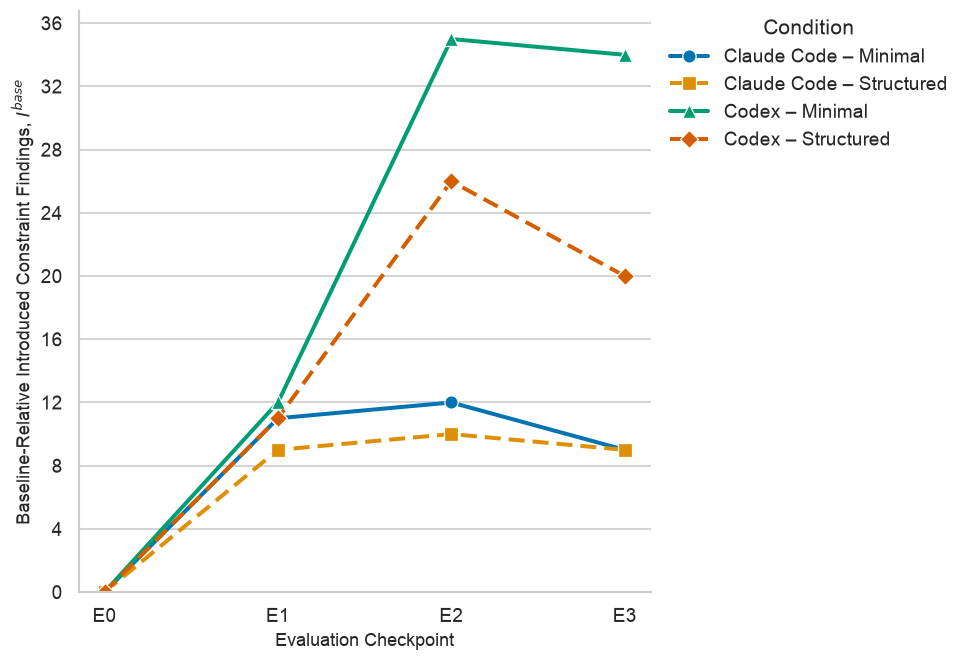

Saved PNG: figures/chapter4/longitudinal_architectural_trajectory.png
Saved PDF: figures/chapter4/longitudinal_architectural_trajectory.pdf
Saved SVG: figures/chapter4/longitudinal_architectural_trajectory.svg


In [21]:
palette = dict(zip(CONDITION_ORDER, sns.color_palette("colorblind", 4)))
markers = {
    "Claude Code – Minimal": "o",
    "Claude Code – Structured": "s",
    "Codex – Minimal": "^",
    "Codex – Structured": "D",
}
dashes = {
    "Claude Code – Minimal": "",
    "Claude Code – Structured": (4, 2),
    "Codex – Minimal": "",
    "Codex – Structured": (4, 2),
}

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(
    data=trajectory_plot,
    x="task",
    y=Y_COLUMN,
    hue="condition",
    style="condition",
    hue_order=CONDITION_ORDER,
    style_order=CONDITION_ORDER,
    palette=palette,
    markers=markers,
    dashes=dashes,
    linewidth=2.4,
    markersize=8,
    estimator=None,
    sort=False,
    ax=ax,
)

ax.set_xlabel("Evaluation Checkpoint")
ax.set_ylabel(r"Baseline-Relative Introduced Constraint Findings, $I^{base}$")
ax.set_xticks(range(len(CHECKPOINT_ORDER)), CHECKPOINT_ORDER)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_ylim(bottom=0)
ax.grid(axis="x", visible=False)
ax.legend(
    title="Condition",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0,
)
sns.despine(ax=ax)
fig.text(
    0.01, 0.01,
    "",
    ha="left", va="bottom", fontsize=9, color="dimgray",
)
fig.tight_layout(rect=(0, 0.05, 0.83, 1))

png_path = FIGURE_DIR / "longitudinal_architectural_trajectory.png"
pdf_path = FIGURE_DIR / "longitudinal_architectural_trajectory.pdf"
svg_path = FIGURE_DIR / "longitudinal_architectural_trajectory.svg"
fig.savefig(png_path, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(svg_path, format="svg", bbox_inches="tight")
plt.show()

print(f"Saved PNG: {png_path.relative_to(ANALYSIS_DIR)}")
print(f"Saved PDF: {pdf_path.relative_to(ANALYSIS_DIR)}")
print(f"Saved SVG: {svg_path.relative_to(ANALYSIS_DIR)}")

### Figure audit

The plotted values are baseline-relative introduced findings, not absolute findings and not baseline-relative net change. The chart contains four condition lines and four ordered checkpoints per line.

In [22]:
figure_audit = pd.DataFrame({
    "check": [
        "Dataset A source column",
        "Number of condition lines",
        "Checkpoints per line",
        "E0 values equal zero",
        "PNG exists",
        "PDF exists",
    ],
    "result": [
        Y_COLUMN,
        trajectory_plot["condition"].nunique(),
        int(trajectory_plot.groupby("condition", observed=True)["task"].size().min()),
        bool(trajectory_plot.loc[trajectory_plot["task"].eq("E0"), Y_COLUMN].eq(0).all()),
        png_path.exists(),
        pdf_path.exists(),
    ],
})
display(figure_audit)
print("Figure 1 generated and validated successfully.")

,check,result
0,Dataset A source column,baseline_relative_introduced_findings
1,Number of condition lines,4
2,Checkpoints per line,4
3,E0 values equal zero,True
4,PNG exists,True
5,PDF exists,True


Figure 1 generated and validated successfully.


## 3. Figure 2 — Architectural Concern Profile

**Source:** Dataset B  
**Chart:** Heatmap  
**Rows:** 19 architectural concerns in canonical Backend → Frontend → Cross-Stack order  
**Columns:** Claude – Minimal, Claude – Structured, Codex – Minimal, and Codex – Structured  
**Cell value:** Task-Local Introduced Findings summed across T1–T3

For condition $(a,p)$ and concern $c$, each cell is:

$$\sum_{k=1}^{3} I^{local}_{a,p,k,c}$$

This directly answers which architectural concerns each agent–prompt condition introduced during development. Baseline-relative active or absolute findings averaged across checkpoints are deliberately not used.

In [23]:
B_VALUE_COLUMN = "task_local_introduced_findings"
required_b_columns = {"agent", "strategy", "task", "concern", "layer", B_VALUE_COLUMN}
missing_b_columns = required_b_columns.difference(dataset_b.columns)
assert not missing_b_columns, f"Dataset B is missing required columns: {sorted(missing_b_columns)}"

concern_index = dataset_b[["concern", "layer"]].drop_duplicates().reset_index(drop=True)
CONCERN_ORDER = concern_index["concern"].tolist()
assert len(CONCERN_ORDER) == 19
assert concern_index["layer"].tolist() == sorted(
    concern_index["layer"].tolist(),
    key=lambda layer: {"backend": 0, "frontend": 1, "cross-stack": 2}[layer],
)

concern_totals = dataset_b.loc[dataset_b["task"].isin(["T1", "T2", "T3"])].copy()
concern_totals["condition"] = (
    concern_totals["agent"].replace({"claude": "Claude Code", "codex": "Codex"})
    + " – " + concern_totals["strategy"].str.title()
)
concern_totals = (
    concern_totals.groupby(["concern", "condition"], as_index=False)[B_VALUE_COLUMN]
    .sum()
)
concern_heatmap = (
    concern_totals.pivot(index="concern", columns="condition", values=B_VALUE_COLUMN)
    .reindex(index=CONCERN_ORDER, columns=CONDITION_ORDER)
    .fillna(0)
    .astype(int)
)

assert concern_heatmap.shape == (19, 4)
assert concern_heatmap.ge(0).all().all()

# Cross-dataset audit: summing all concerns must reproduce Dataset A's
# total Task-Local Introduced Findings for each condition across T1–T3.
a_condition_totals = dataset_a.copy()
a_condition_totals["condition"] = (
    a_condition_totals["agent"].replace({"claude": "Claude Code", "codex": "Codex"})
    + " – " + a_condition_totals["strategy"].str.title()
)
a_condition_totals = (
    a_condition_totals.groupby("condition")["task_local_introduced_findings"].sum()
    .reindex(CONDITION_ORDER).astype(int)
)
assert concern_heatmap.sum(axis=0).equals(a_condition_totals)

display(concern_heatmap)
display(pd.DataFrame({
    "Dataset B concern sum": concern_heatmap.sum(axis=0),
    "Dataset A checkpoint sum": a_condition_totals,
}))

condition,Claude Code – Minimal,Claude Code – Structured,Codex – Minimal,Codex – Structured
concern,,,,
BE-STRUCT,0,0,0,0
BE-DEP,0,2,0,0
BE-DOM,2,0,3,0
BE-ERR,0,0,28,18
BE-CONTRACT,11,7,13,12
BE-ROUTE,0,0,0,0
BE-SIZE,1,0,0,0
BE-DUP,0,7,4,10
BE-TEST,0,0,0,0


,Dataset B concern sum,Dataset A checkpoint sum
condition,,
Claude Code – Minimal,22,22
Claude Code – Structured,21,21
Codex – Minimal,58,58
Codex – Structured,47,47


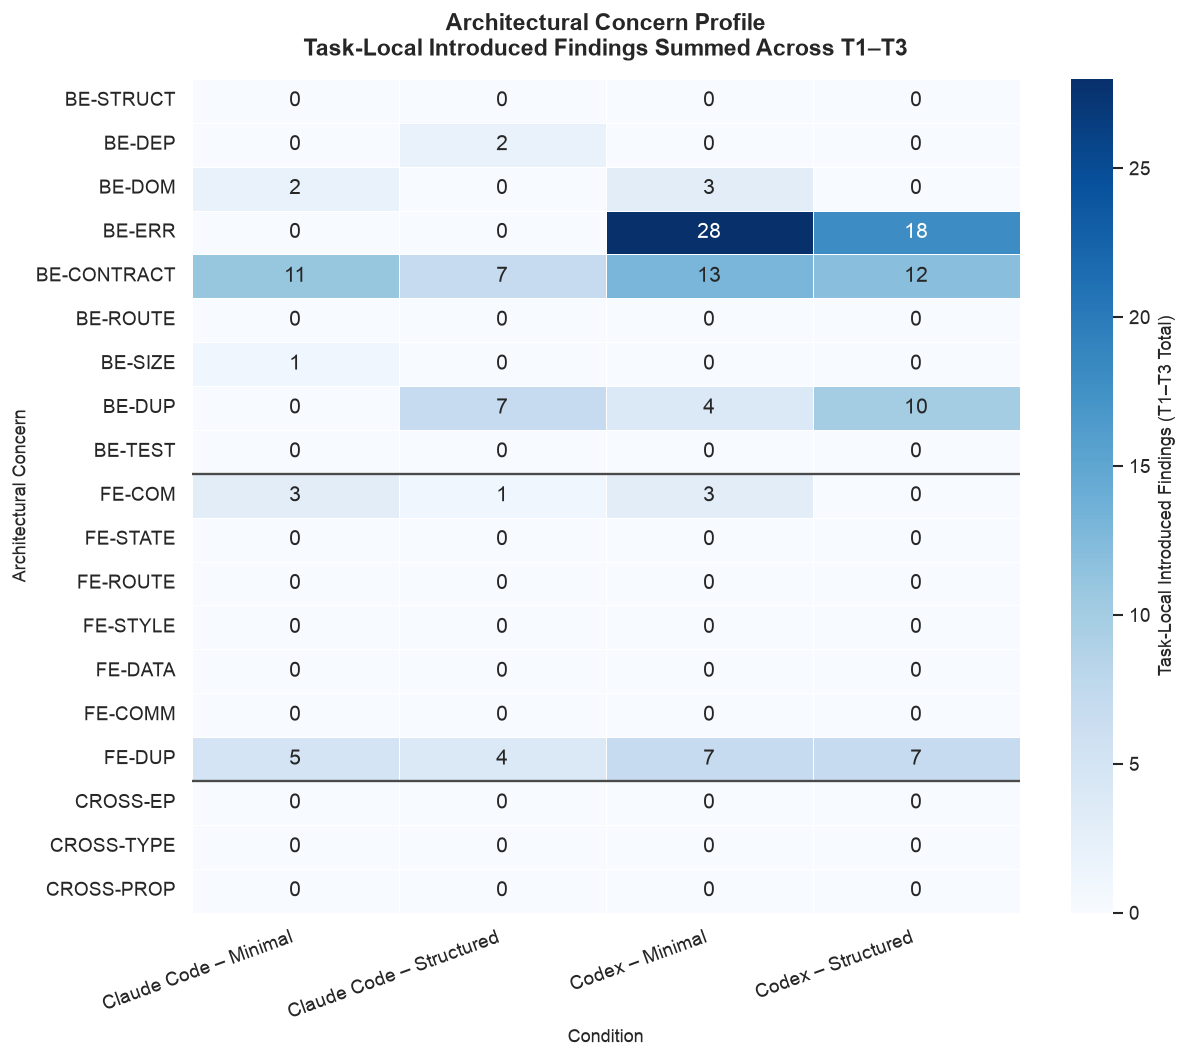

Saved PNG: figures/chapter4/architectural_concern_profile.png
Saved PDF: figures/chapter4/architectural_concern_profile.pdf
Saved SVG: figures/chapter4/architectural_concern_profile.svg


In [24]:
fig, ax = plt.subplots(figsize=(10.5, 9))
heatmap = sns.heatmap(
    concern_heatmap,
    cmap="Blues",
    annot=True,
    fmt="d",
    linewidths=0.6,
    linecolor="white",
    vmin=0,
    cbar_kws={"label": "Task-Local Introduced Findings (T1–T3 Total)"},
    ax=ax,
)

# Separate the three architectural layers while retaining one canonical heatmap.
layer_sizes = concern_index.groupby("layer", sort=False).size().tolist()
for boundary in pd.Series(layer_sizes).cumsum().iloc[:-1]:
    ax.axhline(boundary, color="#4a4a4a", linewidth=1.4)

ax.set_title(
    "Architectural Concern Profile\nTask-Local Introduced Findings Summed Across T1–T3",
    pad=14,
)
ax.set_xlabel("Condition")
ax.set_ylabel("Architectural Concern")
ax.tick_params(axis="x", rotation=20)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")
ax.tick_params(axis="y", rotation=0)
fig.tight_layout()

concern_png_path = FIGURE_DIR / "architectural_concern_profile.png"
concern_pdf_path = FIGURE_DIR / "architectural_concern_profile.pdf"
concern_svg_path = FIGURE_DIR / "architectural_concern_profile.svg"
fig.savefig(concern_png_path, bbox_inches="tight")
fig.savefig(concern_pdf_path, bbox_inches="tight")
fig.savefig(concern_svg_path, format="svg", bbox_inches="tight")
plt.show()

print(f"Saved PNG: {concern_png_path.relative_to(ANALYSIS_DIR)}")
print(f"Saved PDF: {concern_pdf_path.relative_to(ANALYSIS_DIR)}")
print(f"Saved SVG: {concern_svg_path.relative_to(ANALYSIS_DIR)}")

### Figure audit

The heatmap uses introductions attributable to individual development tasks. It does not use averaged checkpoint activity, absolute findings, or baseline-relative net change.

In [25]:
concern_figure_audit = pd.DataFrame({
    "check": [
        "Dataset B source column",
        "Architectural concerns",
        "Condition columns",
        "Concern sum reconciles with Dataset A",
        "PNG exists",
        "PDF exists",
    ],
    "result": [
        B_VALUE_COLUMN,
        concern_heatmap.shape[0],
        concern_heatmap.shape[1],
        concern_heatmap.sum(axis=0).equals(a_condition_totals),
        concern_png_path.exists(),
        concern_pdf_path.exists(),
    ],
})
display(concern_figure_audit)
print("Figure 2 generated and validated successfully.")

,check,result
0,Dataset B source column,task_local_introduced_findings
1,Architectural concerns,19
2,Condition columns,4
3,Concern sum reconciles with Dataset A,True
4,PNG exists,True
5,PDF exists,True


Figure 2 generated and validated successfully.


## 4. Figure 3 — Agent-Specific Architectural Concern Profile

**Source:** Dataset B  
**Chart:** Horizontal grouped bar chart  
**Y-axis:** Architectural concern  
**X-axis:** Task-Local Introduced Constraint Findings  
**Series:** Claude and Codex

Counts are aggregated across T1–T3 and both prompt conditions for each agent. Concerns with zero findings for both agents are omitted, and the remaining concerns are sorted by their combined finding count in descending order. Reader-facing concern names are controlled by the `CONCERN_DISPLAY_LABELS` configuration in the next cell.

In [42]:
AGENT_CONCERN_VALUE_COLUMN = "task_local_introduced_findings"
AGENT_ORDER_RAW = ["claude", "codex"]
AGENT_DISPLAY_NAMES = {"claude": "Claude Code", "codex": "Codex"}

# Reader-facing Figure 3 labels are configured here. Add or edit one entry
# without changing the underlying concern IDs used for aggregation.
CONCERN_DISPLAY_LABELS = {
    "BE-ERR": "Transaction and Error Boundaries",
    "BE-CONTRACT": "Data-Contract Stability",
    "FE-DUP": "Component/Logic Reusability",
    "BE-DUP": "Resource/Logic Duplication",
    "FE-COM": "Component Granularity",
    "BE-DOM": "Domain Boundaries",
    "BE-DEP": "Dependency Direction",
    "BE-SIZE": "Unit Complexity",
}

required_agent_concern_columns = {
    "agent", "strategy", "task", "concern", AGENT_CONCERN_VALUE_COLUMN
}
missing_agent_concern_columns = required_agent_concern_columns.difference(dataset_b.columns)
assert not missing_agent_concern_columns, (
    f"Dataset B is missing required columns: {sorted(missing_agent_concern_columns)}"
)

agent_concern_totals = (
    dataset_b.loc[dataset_b["task"].isin(["T1", "T2", "T3"])]
    .groupby(["concern", "agent"], as_index=False)[AGENT_CONCERN_VALUE_COLUMN]
    .sum()
)
agent_concern_matrix = (
    agent_concern_totals.pivot(
        index="concern", columns="agent", values=AGENT_CONCERN_VALUE_COLUMN
    )
    .reindex(index=CONCERN_ORDER, columns=AGENT_ORDER_RAW)
    .fillna(0)
    .astype(int)
)
agent_concern_matrix["combined_total"] = agent_concern_matrix[AGENT_ORDER_RAW].sum(axis=1)
agent_concern_matrix["canonical_rank"] = range(len(agent_concern_matrix))
agent_concern_matrix = (
    agent_concern_matrix.loc[agent_concern_matrix["combined_total"].gt(0)]
    .sort_values(["combined_total", "canonical_rank"], ascending=[False, True])
)

# Cross-dataset audit: aggregating concerns for each agent must reproduce
# Dataset A totals across the same two prompt conditions and three tasks.
dataset_a_agent_totals = (
    dataset_a.groupby("agent")[AGENT_CONCERN_VALUE_COLUMN]
    .sum().reindex(AGENT_ORDER_RAW).astype(int)
)
dataset_b_agent_totals = agent_concern_matrix[AGENT_ORDER_RAW].sum(axis=0)
assert dataset_b_agent_totals.equals(dataset_a_agent_totals)
assert agent_concern_matrix["combined_total"].gt(0).all()
assert agent_concern_matrix["combined_total"].is_monotonic_decreasing

agent_concern_display = agent_concern_matrix[AGENT_ORDER_RAW].rename(
    columns=AGENT_DISPLAY_NAMES
)
agent_concern_axis_labels = [
    (
        f"{concern} — {CONCERN_DISPLAY_LABELS[concern]}"
        if concern in CONCERN_DISPLAY_LABELS
        else concern
    )
    for concern in agent_concern_display.index
]
assert len(agent_concern_axis_labels) == len(agent_concern_display)
display(agent_concern_display)
print(
    f"Included {len(agent_concern_display)} non-zero concerns; "
    f"omitted {len(CONCERN_ORDER) - len(agent_concern_display)} all-zero concerns."
)

agent,Claude Code,Codex
concern,,
BE-ERR,0,46
BE-CONTRACT,18,25
FE-DUP,9,14
BE-DUP,7,14
FE-COM,4,3
BE-DOM,2,3
BE-DEP,2,0
BE-SIZE,1,0


Included 8 non-zero concerns; omitted 11 all-zero concerns.


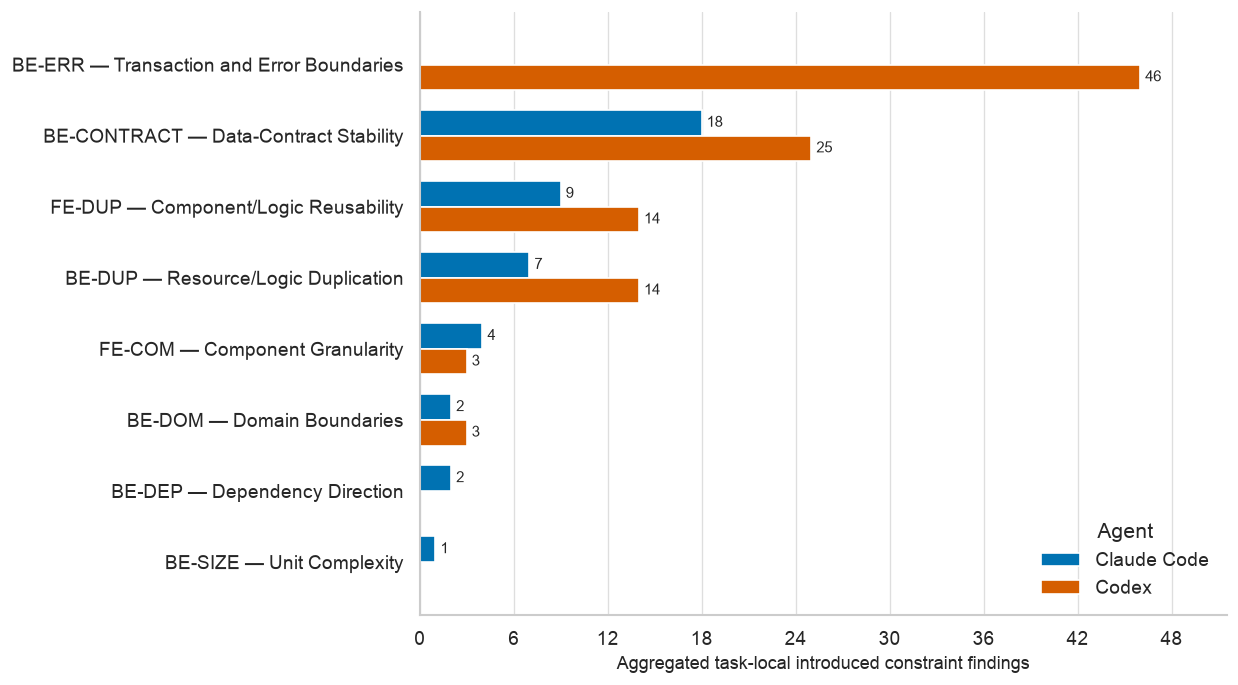

Saved PNG: figures/chapter4/agent_architectural_concern_profile.png
Saved PDF: figures/chapter4/agent_architectural_concern_profile.pdf
Saved SVG: figures/chapter4/agent_architectural_concern_profile.svg


In [43]:
agent_profile_colors = {"Claude Code": "#0072B2", "Codex": "#D55E00"}
concern_positions = pd.Series(range(len(agent_concern_display)), dtype=float).to_numpy()
bar_height = 0.36

fig_height = max(5.8, 0.55 * len(agent_concern_display) + 1.8)
fig, ax = plt.subplots(figsize=(10.5, fig_height))
claude_bars = ax.barh(
    concern_positions - bar_height / 2, agent_concern_display["Claude Code"],
    height=bar_height, color=agent_profile_colors["Claude Code"], label="Claude Code",
)
codex_bars = ax.barh(
    concern_positions + bar_height / 2, agent_concern_display["Codex"],
    height=bar_height, color=agent_profile_colors["Codex"], label="Codex",
)

for bars in (claude_bars, codex_bars):
    ax.bar_label(
        bars,
        labels=[str(int(bar.get_width())) if bar.get_width() > 0 else "" for bar in bars],
        padding=3, fontsize=9,
    )

max_agent_concern_count = int(agent_concern_display.to_numpy().max())
ax.set_yticks(concern_positions, agent_concern_axis_labels)
ax.invert_yaxis()
ax.set_xlim(0, max_agent_concern_count + max(2, max_agent_concern_count * 0.12))
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_xlabel("Aggregated task-local introduced constraint findings")
ax.legend(title="Agent", loc="lower right")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", color="#dedede", linewidth=0.8)
sns.despine(ax=ax)
fig.tight_layout(rect=(0, 0.05, 1, 1))

agent_concern_png_path = FIGURE_DIR / "agent_architectural_concern_profile.png"
agent_concern_pdf_path = FIGURE_DIR / "agent_architectural_concern_profile.pdf"
agent_concern_svg_path = FIGURE_DIR / "agent_architectural_concern_profile.svg"
fig.savefig(agent_concern_png_path, bbox_inches="tight")
fig.savefig(agent_concern_pdf_path, bbox_inches="tight")
fig.savefig(agent_concern_svg_path, format="svg", bbox_inches="tight")
plt.show()

print(f"Saved PNG: {agent_concern_png_path.relative_to(ANALYSIS_DIR)}")
print(f"Saved PDF: {agent_concern_pdf_path.relative_to(ANALYSIS_DIR)}")
print(f"Saved SVG: {agent_concern_svg_path.relative_to(ANALYSIS_DIR)}")

### Figure audit

This chart isolates the agent dimension: the two prompt conditions are aggregated within each agent. It uses integer totals rather than means because both agents have equal exposure (two prompts × three tasks).

In [28]:
agent_concern_figure_audit = pd.DataFrame({
    "check": [
        "Dataset B source column",
        "Non-zero concerns shown",
        "All-zero concerns omitted",
        "Sorted by combined total descending",
        "Displayed concerns have configured labels",
        "Agent totals reconcile with Dataset A",
        "PNG exists",
        "PDF exists",
    ],
    "result": [
        AGENT_CONCERN_VALUE_COLUMN,
        len(agent_concern_display),
        len(CONCERN_ORDER) - len(agent_concern_display),
        agent_concern_matrix["combined_total"].is_monotonic_decreasing,
        all(concern in CONCERN_DISPLAY_LABELS for concern in agent_concern_display.index),
        dataset_b_agent_totals.equals(dataset_a_agent_totals),
        agent_concern_png_path.exists(),
        agent_concern_pdf_path.exists(),
    ],
})
display(agent_concern_figure_audit)
print("Figure 3 generated and validated successfully.")

,check,result
0,Dataset B source column,task_local_introduced_findings
1,Non-zero concerns shown,8
2,All-zero concerns omitted,11
3,Sorted by combined total descending,True
4,Displayed concerns have configured labels,True
5,Agent totals reconcile with Dataset A,True
6,PNG exists,True
7,PDF exists,True


Figure 3 generated and validated successfully.


## 5. Figure 4 — Prompt-Condition Differences in Task-Local Introduced Constraint Findings

**Source:** Dataset A  
**Chart:** Zero-centred diverging horizontal bar chart  
**Y-axis:** Agent–task pair  
**X-axis:** Structured − Minimal difference in Task-Local Introduced Findings, $\Delta I^{prompt}$  
**Color:** Agent

For every matched `agent × task` pair, the plotted quantity is:

$$\Delta I^{prompt}_{a,k} = I^{local}_{a,\mathrm{Structured},k} - I^{local}_{a,\mathrm{Minimal},k}$$

Negative values indicate fewer findings under Structured prompting; positive values indicate more. The vertical zero line means no difference between the prompt conditions.

In [29]:
PROMPT_VALUE_COLUMN = "task_local_introduced_findings"
TASK_ORDER = ["T1", "T2", "T3"]
AGENT_ORDER = ["claude", "codex"]
STRATEGY_ORDER = ["minimal", "structured"]

required_prompt_columns = {"agent", "strategy", "task", PROMPT_VALUE_COLUMN}
missing_prompt_columns = required_prompt_columns.difference(dataset_a.columns)
assert not missing_prompt_columns, f"Dataset A is missing required columns: {sorted(missing_prompt_columns)}"

prompt_long = dataset_a.loc[
    dataset_a["task"].isin(TASK_ORDER),
    ["agent", "strategy", "task", PROMPT_VALUE_COLUMN],
].copy()
prompt_comparison = (
    prompt_long.pivot(index=["agent", "task"], columns="strategy", values=PROMPT_VALUE_COLUMN)
    .reindex(columns=STRATEGY_ORDER)
    .reset_index()
)
prompt_comparison["task"] = pd.Categorical(
    prompt_comparison["task"], categories=TASK_ORDER, ordered=True
)
prompt_comparison = prompt_comparison.sort_values(["agent", "task"]).reset_index(drop=True)

assert prompt_comparison.shape == (6, 4)
assert prompt_comparison[STRATEGY_ORDER].notna().all().all()
assert prompt_comparison.groupby("agent", observed=True)["task"].size().eq(3).all()

prompt_comparison["delta_prompt"] = (
    prompt_comparison["structured"] - prompt_comparison["minimal"]
)
prompt_comparison["delta_prompt"] = prompt_comparison["delta_prompt"].astype(int)

expected_prompt_differences = {
    ("claude", "T1"): -2,
    ("claude", "T2"): -1,
    ("claude", "T3"): 2,
    ("codex", "T1"): -1,
    ("codex", "T2"): -8,
    ("codex", "T3"): -2,
}
actual_prompt_differences = {
    (row.agent, str(row.task)): int(row.delta_prompt)
    for row in prompt_comparison.itertuples(index=False)
}
assert actual_prompt_differences == expected_prompt_differences

prompt_difference_plot = prompt_comparison.sort_values(
    ["delta_prompt", "agent", "task"]
).reset_index(drop=True)
prompt_difference_plot["agent_display"] = prompt_difference_plot["agent"].map(
    AGENT_DISPLAY_NAMES
)
prompt_difference_plot["agent_task_pair"] = (
    prompt_difference_plot["agent_display"]
    + " – "
    + prompt_difference_plot["task"].astype(str)
)
display(prompt_difference_plot[[
    "agent_display", "task", "minimal", "structured", "delta_prompt"
]].rename(columns={
    "agent_display": "Agent",
    "task": "Task",
    "minimal": "Minimal",
    "structured": "Structured",
    "delta_prompt": r"$\Delta I^{prompt}$",
}))

strategy,Agent,Task,Minimal,Structured,$\Delta I^{prompt}$
0,Codex,T2,31,23,-8
1,Claude Code,T1,11,9,-2
2,Codex,T3,15,13,-2
3,Claude Code,T2,9,8,-1
4,Codex,T1,12,11,-1
5,Claude Code,T3,2,4,2


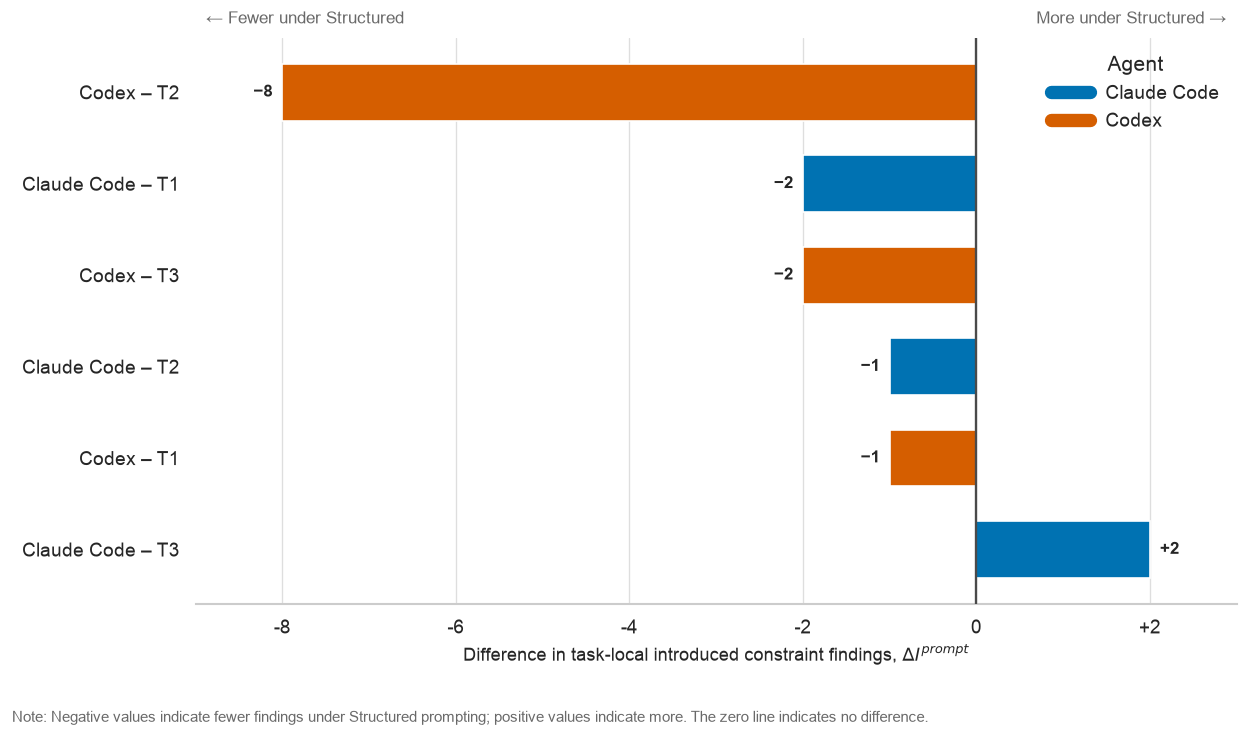

Saved PNG: figures/chapter4/prompt_condition_differences.png
Saved PDF: figures/chapter4/prompt_condition_differences.pdf
Saved SVG: figures/chapter4/prompt_condition_differences.svg


In [30]:
prompt_agent_colors = {
    agent: agent_profile_colors[display_name]
    for agent, display_name in AGENT_DISPLAY_NAMES.items()
}
prompt_positions = pd.Series(range(len(prompt_difference_plot)), dtype=float).to_numpy()
prompt_differences = prompt_difference_plot["delta_prompt"].astype(int)
prompt_colors = prompt_difference_plot["agent"].map(prompt_agent_colors)

fig, ax = plt.subplots(figsize=(10.5, 6.2))
bars = ax.barh(
    prompt_positions, prompt_differences, height=0.62, color=prompt_colors, zorder=2
)

for bar, value in zip(bars, prompt_differences):
    label = f"{int(value):+d}" if value > 0 else str(int(value))
    label = label.replace("-", "−")
    ax.annotate(
        label,
        xy=(value, bar.get_y() + bar.get_height() / 2),
        xytext=(6 if value >= 0 else -6, 0),
        textcoords="offset points",
        ha="left" if value >= 0 else "right",
        va="center",
        fontsize=10,
        fontweight="bold",
    )

left_limit = min(-1, int(prompt_differences.min()) - 1)
right_limit = max(1, int(prompt_differences.max()) + 1)
ax.set_xlim(left_limit, right_limit)
ax.set_yticks(prompt_positions, prompt_difference_plot["agent_task_pair"])
ax.invert_yaxis()
ax.axvline(0, color="#4a4a4a", linewidth=1.4, zorder=3)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.xaxis.set_major_formatter(FuncFormatter(
    lambda value, _: f"+{int(value)}" if value > 0 else f"{int(value)}"
))
ax.set_xlabel(
    r"Difference in task-local introduced constraint findings, $\Delta I^{prompt}$"
)
ax.text(
    0.01, 1.02, "← Fewer under Structured",
    transform=ax.transAxes, ha="left", va="bottom", fontsize=10, color="dimgray",
)
ax.text(
    0.99, 1.02, "More under Structured →",
    transform=ax.transAxes, ha="right", va="bottom", fontsize=10, color="dimgray",
)
legend_handles = [
    plt.Line2D([0], [0], color=prompt_agent_colors[agent], linewidth=8, label=AGENT_DISPLAY_NAMES[agent])
    for agent in AGENT_ORDER
]
ax.legend(handles=legend_handles, title="Agent", loc="upper right")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", color="#dedede", linewidth=0.8, zorder=0)
sns.despine(ax=ax, left=True)
fig.text(
    0.01, 0.01,
    "Note: Negative values indicate fewer findings under Structured prompting; "
    "positive values indicate more. The zero line indicates no difference.",
    ha="left", va="bottom", fontsize=9, color="dimgray",
)
fig.tight_layout(rect=(0, 0.06, 1, 1))

prompt_png_path = FIGURE_DIR / "prompt_condition_differences.png"
prompt_pdf_path = FIGURE_DIR / "prompt_condition_differences.pdf"
prompt_svg_path = FIGURE_DIR / "prompt_condition_differences.svg"
fig.savefig(prompt_png_path, bbox_inches="tight")
fig.savefig(prompt_pdf_path, bbox_inches="tight")
fig.savefig(prompt_svg_path, format="svg", bbox_inches="tight")
plt.show()

print(f"Saved PNG: {prompt_png_path.relative_to(ANALYSIS_DIR)}")
print(f"Saved PDF: {prompt_pdf_path.relative_to(ANALYSIS_DIR)}")
print(f"Saved SVG: {prompt_svg_path.relative_to(ANALYSIS_DIR)}")

### Figure audit

Each bar is one matched `agent × task` difference calculated in the Chapter 3 direction: Structured minus Minimal. Color identifies the agent; it does not represent either prompt condition.

In [31]:
prompt_figure_audit = pd.DataFrame({
    "check": [
        "Dataset A source column",
        "Agent categories",
        "Matched task pairs",
        "Tasks per agent",
        "Structured − Minimal identity",
        "Negative / positive differences",
        "PNG exists",
        "PDF exists",
    ],
    "result": [
        PROMPT_VALUE_COLUMN,
        prompt_difference_plot["agent"].nunique(),
        len(prompt_comparison),
        int(prompt_comparison.groupby("agent", observed=True)["task"].size().min()),
        bool(prompt_comparison["delta_prompt"].eq(
            prompt_comparison["structured"] - prompt_comparison["minimal"]
        ).all()),
        f"{int(prompt_differences.lt(0).sum())} negative / {int(prompt_differences.gt(0).sum())} positive",
        prompt_png_path.exists(),
        prompt_pdf_path.exists(),
    ],
})
display(prompt_figure_audit)
print("Figure 4 generated and validated successfully.")

,check,result
0,Dataset A source column,task_local_introduced_findings
1,Agent categories,2
2,Matched task pairs,6
3,Tasks per agent,3
4,Structured − Minimal identity,True
5,Negative / positive differences,5 negative / 1 positive
6,PNG exists,True
7,PDF exists,True


Figure 4 generated and validated successfully.


## 6. Figure 4.2 — Silent Deviation Trajectories

**Source:** Dataset C  
**Initial filter:** `silent_decay == True OR constraint_failure == True`  
**Figure 4.2(a):** BE-SIZE trajectory across E0 → E1 → E2 → E3  
**Figure 4.2(b):** BE-DEP trajectory across E0 → E1 → E2 → E3  
**Series:** Claude Code – Minimal, Claude Code – Structured, Codex – Minimal, and Codex – Structured  
**Annotations:** Silent-deviation and corresponding constraint-failure checkpoints are marked directly on the trajectories

Both selected metrics are `lower_is_better`, so higher values are adverse and the relevant Tukey boundary is the upper fence $F^+$. A non-zero metric value alone does not imply silent deviation: the corresponding concern must also have no task-local constraint failure. The plots therefore distinguish metric-only Silent Deviation from Constraint Failure at the point level and use no adverse-region background shading.

In [32]:
flagged_metric_rows = dataset_c.loc[
    dataset_c["silent_decay"] | dataset_c["constraint_failure"]
].copy()
flagged_metric_audit = (
    flagged_metric_rows.groupby(["concern", "metric_id"], as_index=False)
    .agg(
        flagged_cells=("evaluation_id", "size"),
        silent_decay_cells=("silent_decay", "sum"),
        constraint_failure_cells=("constraint_failure", "sum"),
    )
    .sort_values(
        ["silent_decay_cells", "constraint_failure_cells", "flagged_cells"],
        ascending=False,
    )
    .reset_index(drop=True)
)
display(flagged_metric_audit)

silent_decay_metric_specs = [
    {
        "panel": "Figure 4.2(a)",
        "concern": "BE-SIZE",
        "metric_id": "BE-SIZE-M-001-cyclomatic-complexity-ratio",
        "ylabel": r"High-complexity method share $M$",
        "file_stem": "silent_decay_be_size_trajectory",
        "annotation_offsets": {
            ("Claude Code – Minimal", "E2", "Silent Deviation"): (10, 14),
            ("Claude Code – Minimal", "E3", "Constraint Failure"): (-112, -28),
            ("Codex – Minimal", "E3", "Silent Deviation"): (-86, 14),
        },
    },
    {
        "panel": "Figure 4.2(b)",
        "concern": "BE-DEP",
        "metric_id": "BE-DEP-M-001-dependency-violation-density",
        "ylabel": r"Dependency violation density $M$",
        "file_stem": "silent_decay_be_dep_trajectory",
        "annotation_offsets": {
            ("Claude Code – Structured", "E2", "Constraint Failure"): (-112, 18),
            ("Claude Code – Structured", "E3", "Silent Deviation"): (-88, -32),
        },
    },
]

silent_decay_events = dataset_c.loc[
    dataset_c["silent_decay"],
    ["evaluation_id", "agent", "strategy", "task", "concern", "metric_id", "raw_value"],
].copy()
assert len(silent_decay_events) == 3
assert set(silent_decay_events["metric_id"]) == {spec["metric_id"] for spec in silent_decay_metric_specs}
display(silent_decay_events.sort_values(["concern", "evaluation_id"]))

,concern,metric_id,flagged_cells,silent_decay_cells,constraint_failure_cells
0,BE-SIZE,BE-SIZE-M-001-cyclomatic-complexity-ratio,3,2,1
1,BE-DEP,BE-DEP-M-001-dependency-violation-density,2,1,1
2,FE-DUP,FE-DUP-M-001-clone-ratio,11,0,11
3,BE-CONTRACT,BE-CONTRACT-M-001-dto-validator-coverage,8,0,8
4,BE-DUP,BE-DUP-M-001-clone-ratio,7,0,7
5,BE-ERR,BE-ERR-M-001-exception-unification-violation-d...,5,0,5
6,FE-COM,FE-COM-M-001-render-decision-depth-average,5,0,5
7,BE-DOM,BE-DOM-M-001-cross-module-deep-import-count,4,0,4


,evaluation_id,agent,strategy,task,concern,metric_id,raw_value
96,session_20260817_160757/T3,claude,structured,T3,BE-DEP,BE-DEP-M-001-dependency-violation-density,0.020202
25,session_20260817_130253/T2,claude,minimal,T2,BE-SIZE,BE-SIZE-M-001-cyclomatic-complexity-ratio,0.023810
158,session_20260817_210911/T3,codex,minimal,T3,BE-SIZE,BE-SIZE-M-001-cyclomatic-complexity-ratio,0.015152


In [33]:
def build_silent_decay_panel(spec):
    metric_rows = dataset_c.loc[dataset_c["metric_id"].eq(spec["metric_id"])].copy()
    assert not metric_rows.empty
    assert metric_rows["concern"].eq(spec["concern"]).all()
    metric_rows["condition"] = (
        metric_rows["agent"].replace({"claude": "Claude Code", "codex": "Codex"})
        + " – " + metric_rows["strategy"].str.title()
    )
    metric_rows["state"] = (
        pd.Series("Clean", index=metric_rows.index)
        .mask(metric_rows["silent_decay"], "Silent Deviation")
        .mask(metric_rows["constraint_failure"], "Constraint Failure")
    )

    baseline_values = metric_rows["baseline_value"].dropna().unique()
    assert len(baseline_values) == 1
    baseline_value = float(baseline_values[0])
    baseline_metric_points = (
        metric_rows[["condition", "agent", "strategy"]]
        .drop_duplicates()
        .assign(task="E0", raw_value=baseline_value, state="Clean")
    )
    metric_trajectory = pd.concat([
        baseline_metric_points[["condition", "agent", "strategy", "task", "raw_value", "state"]],
        metric_rows[["condition", "agent", "strategy", "task", "raw_value", "state"]],
    ], ignore_index=True)
    metric_trajectory["task"] = metric_trajectory["task"].replace(
        {"T1": "E1", "T2": "E2", "T3": "E3"}
    )
    metric_trajectory["task"] = pd.Categorical(
        metric_trajectory["task"], categories=CHECKPOINT_ORDER, ordered=True
    )
    metric_trajectory["condition"] = pd.Categorical(
        metric_trajectory["condition"], categories=CONDITION_ORDER, ordered=True
    )
    metric_trajectory["checkpoint_position"] = metric_trajectory["task"].map(
        {checkpoint: index + 0.5 for index, checkpoint in enumerate(CHECKPOINT_ORDER)}
    ).astype(float)
    metric_trajectory = metric_trajectory.sort_values(["condition", "task"]).reset_index(drop=True)

    directions = metric_rows["direction"].dropna().unique()
    assert directions.tolist() == ["lower_is_better"]
    fence_values = metric_rows["upper_fence"].dropna().unique()
    assert len(fence_values) == 1

    assert metric_trajectory.groupby("condition", observed=True)["task"].size().eq(4).all()
    assert metric_trajectory.loc[metric_trajectory["task"].eq("E0"), "raw_value"].eq(baseline_value).all()
    return {
        **spec,
        "trajectory": metric_trajectory,
        "baseline_value": baseline_value,
        "tukey_fence": float(fence_values[0]),
    }


silent_decay_panels = {
    spec["concern"]: build_silent_decay_panel(spec)
    for spec in silent_decay_metric_specs
}
for concern, panel in silent_decay_panels.items():
    print(f"{panel['panel']} {concern}; upper_fence={panel['tukey_fence']:.6f}")
    display(panel["trajectory"][["condition", "task", "raw_value", "state"]])

Figure 4.2(a) BE-SIZE; upper_fence=0.000000


,condition,task,raw_value,state
0,Claude Code – Minimal,E0,0.000000,Clean
1,Claude Code – Minimal,E1,0.000000,Clean
2,Claude Code – Minimal,E2,0.023810,Silent Deviation
3,Claude Code – Minimal,E3,0.044444,Constraint Failure
4,Claude Code – Structured,E0,0.000000,Clean
5,Claude Code – Structured,E1,0.000000,Clean
6,Claude Code – Structured,E2,0.000000,Clean
7,Claude Code – Structured,E3,0.000000,Clean
8,Codex – Minimal,E0,0.000000,Clean
9,Codex – Minimal,E1,0.000000,Clean


Figure 4.2(b) BE-DEP; upper_fence=0.000000


,condition,task,raw_value,state
0,Claude Code – Minimal,E0,0.000000,Clean
1,Claude Code – Minimal,E1,0.000000,Clean
2,Claude Code – Minimal,E2,0.000000,Clean
3,Claude Code – Minimal,E3,0.000000,Clean
4,Claude Code – Structured,E0,0.000000,Clean
5,Claude Code – Structured,E1,0.000000,Clean
6,Claude Code – Structured,E2,0.020833,Constraint Failure
7,Claude Code – Structured,E3,0.020202,Silent Deviation
8,Codex – Minimal,E0,0.000000,Clean
9,Codex – Minimal,E1,0.000000,Clean


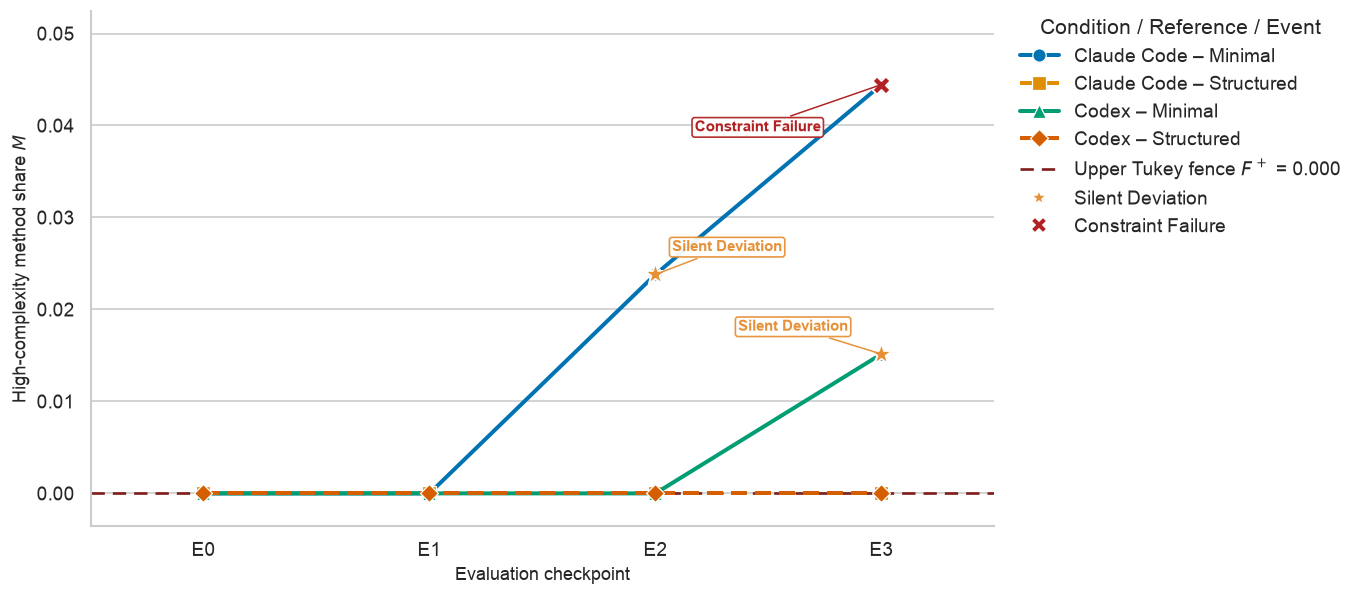

Saved BE-SIZE PNG: figures/chapter4/silent_decay_be_size_trajectory.png
Saved BE-SIZE PDF: figures/chapter4/silent_decay_be_size_trajectory.pdf
Saved BE-SIZE SVG: figures/chapter4/silent_decay_be_size_trajectory.svg


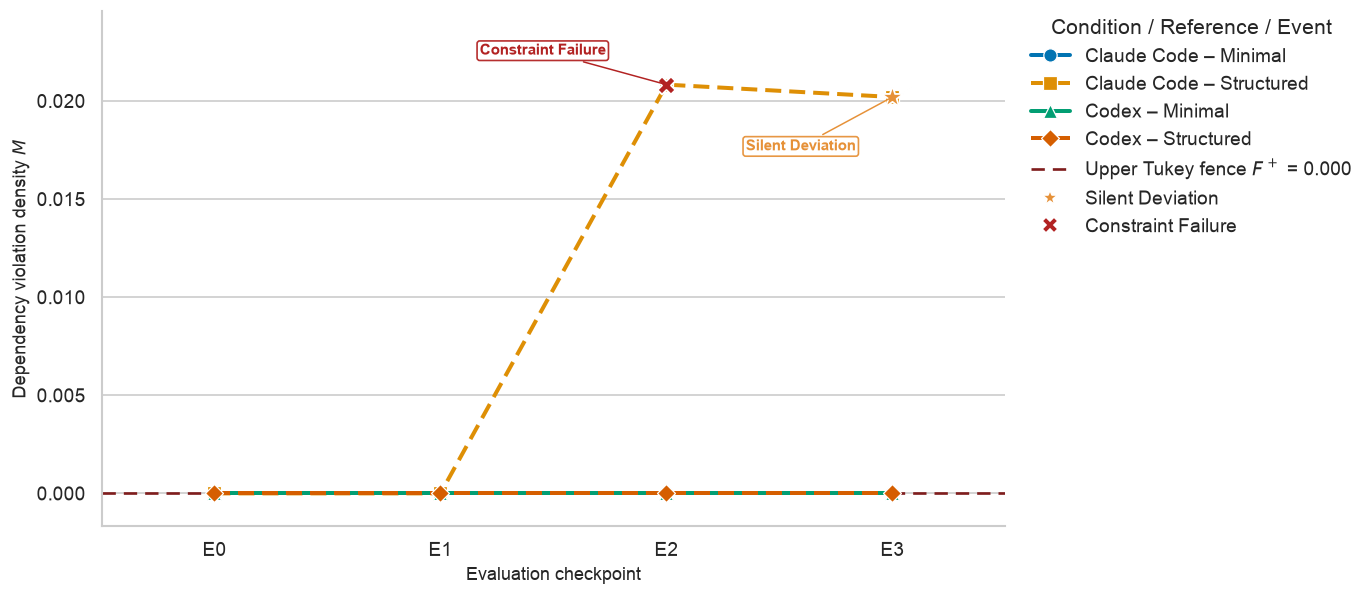

Saved BE-DEP PNG: figures/chapter4/silent_decay_be_dep_trajectory.png
Saved BE-DEP PDF: figures/chapter4/silent_decay_be_dep_trajectory.pdf
Saved BE-DEP SVG: figures/chapter4/silent_decay_be_dep_trajectory.svg


In [34]:
from matplotlib.lines import Line2D

event_styles = {
    "Silent Deviation": {"color": "#E69138", "marker": "*", "size": 190},
    "Constraint Failure": {"color": "#B22222", "marker": "X", "size": 115},
}


def plot_silent_decay_panel(panel):
    metric_trajectory = panel["trajectory"]
    tukey_fence = panel["tukey_fence"]
    fig, ax = plt.subplots(figsize=(11.5, 5.8))

    sns.lineplot(
        data=metric_trajectory,
        x="checkpoint_position",
        y="raw_value",
        hue="condition",
        style="condition",
        hue_order=CONDITION_ORDER,
        style_order=CONDITION_ORDER,
        palette=palette,
        markers=markers,
        dashes=dashes,
        linewidth=2.4,
        markersize=8,
        estimator=None,
        sort=False,
        ax=ax,
    )
    ax.axhline(
        tukey_fence, color="#7F1D1D", linewidth=1.6, linestyle=(0, (5, 3)),
        label=rf"Upper Tukey fence $F^+$ = {tukey_fence:.3f}", zorder=1,
    )

    metric_min = float(metric_trajectory["raw_value"].min())
    metric_max = float(metric_trajectory["raw_value"].max())
    metric_span = max(metric_max - metric_min, metric_max, 0.01)
    ax.set_ylim(min(metric_min, tukey_fence) - metric_span * 0.08, metric_max + metric_span * 0.18)

    event_rows = metric_trajectory.loc[metric_trajectory["state"].ne("Clean")].copy()
    for _, event in event_rows.iterrows():
        state = event["state"]
        style = event_styles[state]
        condition = str(event["condition"])
        checkpoint = str(event["task"])
        x_value = float(event["checkpoint_position"])
        y_value = float(event["raw_value"])
        offset = panel["annotation_offsets"].get((condition, checkpoint, state), (8, 12))
        ax.scatter(
            [x_value], [y_value], marker=style["marker"], s=style["size"],
            color=style["color"], edgecolor="white", linewidth=1.1, zorder=6,
        )
        ax.annotate(
            state, xy=(x_value, y_value), xytext=offset, textcoords="offset points",
            fontsize=9, fontweight="bold", color=style["color"],
            arrowprops={"arrowstyle": "-", "color": style["color"], "lw": 0.9},
            bbox={"boxstyle": "round,pad=0.18", "fc": "white", "ec": style["color"], "alpha": 0.94},
            zorder=7,
        )

    ax.set_ylabel(panel["ylabel"])
    ax.set_xlabel("Evaluation checkpoint")
    ax.set_xlim(0, len(CHECKPOINT_ORDER))
    ax.set_xticks([index + 0.5 for index in range(len(CHECKPOINT_ORDER))], CHECKPOINT_ORDER)
    ax.tick_params(axis="x", rotation=0)
    ax.grid(axis="x", visible=False)

    handles, labels = ax.get_legend_handles_labels()
    event_handles = [
        Line2D(
            [0], [0], marker=style["marker"], linestyle="None",
            markerfacecolor=style["color"], markeredgecolor="white",
            markersize=10, label=state,
        )
        for state, style in event_styles.items()
    ]
    ax.legend(
        handles + event_handles, labels + list(event_styles), title="Condition / Reference / Event",
        loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0,
    )
    sns.despine(ax=ax)
    fig.subplots_adjust(right=0.78, top=0.88, bottom=0.14)

    png_path = FIGURE_DIR / f"{panel['file_stem']}.png"
    pdf_path = FIGURE_DIR / f"{panel['file_stem']}.pdf"
    svg_path = FIGURE_DIR / f"{panel['file_stem']}.svg"
    fig.savefig(png_path, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(svg_path, format="svg", bbox_inches="tight")
    plt.show()
    return png_path, pdf_path, svg_path, event_rows


silent_decay_figure_outputs = {}
for concern in ["BE-SIZE", "BE-DEP"]:
    png_path, pdf_path, svg_path, event_rows = plot_silent_decay_panel(silent_decay_panels[concern])
    silent_decay_figure_outputs[concern] = {
        "png": png_path, "pdf": pdf_path, "svg": svg_path, "events": event_rows,
    }
    print(f"Saved {concern} PNG: {png_path.relative_to(ANALYSIS_DIR)}")
    print(f"Saved {concern} PDF: {pdf_path.relative_to(ANALYSIS_DIR)}")
    print(f"Saved {concern} SVG: {svg_path.relative_to(ANALYSIS_DIR)}")

### Figure audit

Constraint Failure takes precedence when a metric is adverse and the same concern also has a task-local constraint failure. Figure 4.2(a) therefore shows Claude Code – Minimal progressing from a metric-only Silent Deviation at E2 to Constraint Failure at E3. Figure 4.2(b) shows Claude Code – Structured at BE-DEP as Constraint Failure at E2, followed by Silent Deviation at E3 when the constraint returns to Pass while the metric remains adverse.

In [35]:
silent_decay_figure_audit = pd.DataFrame([
    {
        "panel": panel["panel"],
        "concern": concern,
        "metric_id": panel["metric_id"],
        "condition_trajectories": panel["trajectory"]["condition"].nunique(),
        "checkpoints_per_trajectory": int(
            panel["trajectory"].groupby("condition", observed=True)["task"].size().min()
        ),
        "silent_decay_markers": int(panel["trajectory"]["state"].eq("Silent Deviation").sum()),
        "constraint_failure_markers": int(panel["trajectory"]["state"].eq("Constraint Failure").sum()),
        "upper_tukey_fence": panel["tukey_fence"],
        "adverse_background_shading": False,
        "png_exists": silent_decay_figure_outputs[concern]["png"].exists(),
        "pdf_exists": silent_decay_figure_outputs[concern]["pdf"].exists(),
        "svg_exists": silent_decay_figure_outputs[concern]["svg"].exists(),
    }
    for concern, panel in silent_decay_panels.items()
])
display(silent_decay_figure_audit)
assert silent_decay_figure_audit["condition_trajectories"].eq(4).all()
assert silent_decay_figure_audit["checkpoints_per_trajectory"].eq(4).all()
assert silent_decay_figure_audit["silent_decay_markers"].sum() == 3
assert silent_decay_figure_audit["constraint_failure_markers"].sum() == 2
assert silent_decay_figure_audit[["png_exists", "pdf_exists", "svg_exists"]].all().all()
print("Figures 4.2(a) and 4.2(b) generated and validated successfully.")

,panel,concern,metric_id,condition_trajectories,checkpoints_per_trajectory,silent_decay_markers,constraint_failure_markers,upper_tukey_fence,adverse_background_shading,png_exists,pdf_exists,svg_exists
0,Figure 4.2(a),BE-SIZE,BE-SIZE-M-001-cyclomatic-complexity-ratio,4,4,2,1,0.0,False,True,True,True
1,Figure 4.2(b),BE-DEP,BE-DEP-M-001-dependency-violation-density,4,4,1,1,0.0,False,True,True,True


Figures 4.2(a) and 4.2(b) generated and validated successfully.


## Figure 4.3 — Constraint–Metric State Classification

**Title:** Constraint–Metric State Classification for Silent-Deviation-Producing Concerns Across E0–E3  
**Source:** The same Dataset C classifications used by Figures 4.2(a) and 4.2(b)  
**Panels:** Two separately exported heatmaps: Figure 4.3(a) BE-SIZE and Figure 4.3(b) BE-DEP  
**Rows per heatmap:** Four agent–prompt conditions  
**Columns:** E0–E3  
**States:** Clean, Silent Deviation, and Constraint Failure

Each concern is shown in its own figure so the two state progressions can be used independently, while every figure preserves all four conditions as comparison references.

task,E0,E1,E2,E3
condition,,,,
Claude Code – Minimal,Clean,Clean,Silent Deviation,Constraint Failure
Claude Code – Structured,Clean,Clean,Clean,Clean
Codex – Minimal,Clean,Clean,Clean,Silent Deviation
Codex – Structured,Clean,Clean,Clean,Clean


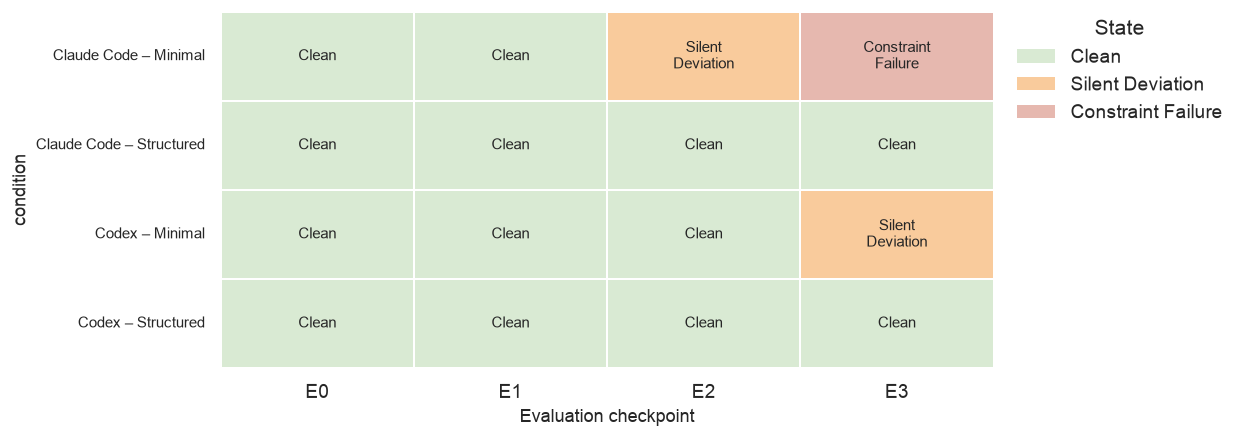

Saved Figure 4.3(a) PNG: figures/chapter4/silent_decay_state_classification_be_size.png
Saved Figure 4.3(a) PDF: figures/chapter4/silent_decay_state_classification_be_size.pdf
Saved Figure 4.3(a) SVG: figures/chapter4/silent_decay_state_classification_be_size.svg


task,E0,E1,E2,E3
condition,,,,
Claude Code – Minimal,Clean,Clean,Clean,Clean
Claude Code – Structured,Clean,Clean,Constraint Failure,Silent Deviation
Codex – Minimal,Clean,Clean,Clean,Clean
Codex – Structured,Clean,Clean,Clean,Clean


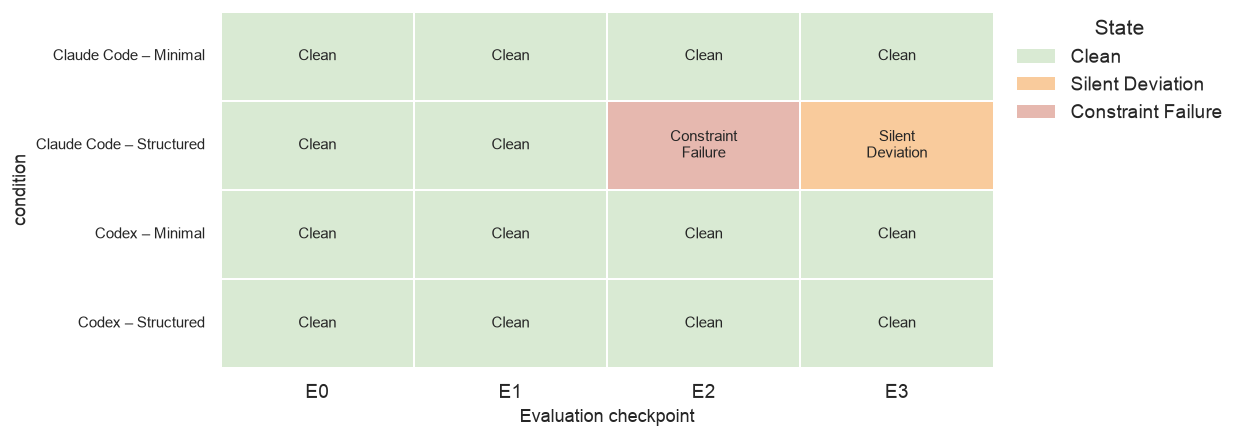

Saved Figure 4.3(b) PNG: figures/chapter4/silent_decay_state_classification_be_dep.png
Saved Figure 4.3(b) PDF: figures/chapter4/silent_decay_state_classification_be_dep.pdf
Saved Figure 4.3(b) SVG: figures/chapter4/silent_decay_state_classification_be_dep.svg


In [36]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

state_order = ["Clean", "Silent Deviation", "Constraint Failure"]
state_cmap = ListedColormap(["#D9EAD3", "#F9CB9C", "#E6B8AF"])
concern_order = ["BE-SIZE", "BE-DEP"]
panel_labels = {"BE-SIZE": "(a)", "BE-DEP": "(b)"}
figure_stems = {
    "BE-SIZE": "silent_decay_state_classification_be_size",
    "BE-DEP": "silent_decay_state_classification_be_dep",
}

state_matrices = {}
figure_43_paths = {}
state_handles = [
    Patch(facecolor=color, edgecolor="none", label=state)
    for state, color in zip(state_order, state_cmap.colors)
]
for concern in concern_order:
    state_matrix = (
        silent_decay_panels[concern]["trajectory"]
        .pivot(index="condition", columns="task", values="state")
        .reindex(index=CONDITION_ORDER, columns=CHECKPOINT_ORDER)
    )
    assert state_matrix.shape == (4, 4)
    assert not state_matrix.isna().any().any()
    state_matrices[concern] = state_matrix
    display(state_matrix.style.set_caption(f"{concern} concern states"))

    state_codes = state_matrix.replace(
        {state: code for code, state in enumerate(state_order)}
    ).astype(int)
    state_annotations = state_matrix.replace({
        "Silent Deviation": "Silent\nDeviation",
        "Constraint Failure": "Constraint\nFailure",
    })

    fig_43, ax_43 = plt.subplots(figsize=(11.5, 4.5))
    sns.heatmap(
        state_codes,
        cmap=state_cmap,
        vmin=-0.5, vmax=2.5,
        annot=state_annotations, fmt="",
        cbar=False, linewidths=1.2, linecolor="white",
        yticklabels=CONDITION_ORDER,
        annot_kws={"fontsize": 9},
        ax=ax_43,
    )
    ax_43.set_xlabel("Evaluation checkpoint")
    ax_43.tick_params(axis="x", rotation=0)
    ax_43.tick_params(axis="y", rotation=0, labelsize=9)
    ax_43.legend(
        handles=state_handles, title="State",
        loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0,
    )
    fig_43.subplots_adjust(right=0.80, left=0.24, top=0.82, bottom=0.16)

    png_path = FIGURE_DIR / f"{figure_stems[concern]}.png"
    pdf_path = FIGURE_DIR / f"{figure_stems[concern]}.pdf"
    svg_path = FIGURE_DIR / f"{figure_stems[concern]}.svg"
    fig_43.savefig(png_path, bbox_inches="tight")
    fig_43.savefig(pdf_path, bbox_inches="tight")
    fig_43.savefig(svg_path, format="svg", bbox_inches="tight")
    figure_43_paths[concern] = {"png": png_path, "pdf": pdf_path, "svg": svg_path}
    plt.show()

    print(f"Saved Figure 4.3{panel_labels[concern]} PNG: {png_path.relative_to(ANALYSIS_DIR)}")
    print(f"Saved Figure 4.3{panel_labels[concern]} PDF: {pdf_path.relative_to(ANALYSIS_DIR)}")
    print(f"Saved Figure 4.3{panel_labels[concern]} SVG: {svg_path.relative_to(ANALYSIS_DIR)}")

assert state_matrices["BE-DEP"].loc["Claude Code – Structured", "E2"] == "Constraint Failure"
assert state_matrices["BE-DEP"].loc["Claude Code – Structured", "E3"] == "Silent Deviation"

In [37]:
figure_43_audit = pd.DataFrame({
    "check": [
        "Separate heatmaps",
        "Rows in BE-SIZE heatmap",
        "Rows in BE-DEP heatmap",
        "Checkpoint columns",
        "Silent Deviation cells",
        "Constraint Failure cells",
        "BE-DEP Claude Code–Structured E2",
        "BE-DEP Claude Code–Structured E3",
        "Both PNGs exist",
        "Both PDFs exist",
        "Both SVGs exist",
    ],
    "result": [
        len(figure_43_paths),
        state_matrices["BE-SIZE"].shape[0],
        state_matrices["BE-DEP"].shape[0],
        state_matrices["BE-SIZE"].shape[1],
        sum(int(matrix.eq("Silent Deviation").sum().sum()) for matrix in state_matrices.values()),
        sum(int(matrix.eq("Constraint Failure").sum().sum()) for matrix in state_matrices.values()),
        state_matrices["BE-DEP"].loc["Claude Code – Structured", "E2"],
        state_matrices["BE-DEP"].loc["Claude Code – Structured", "E3"],
        all(paths["png"].exists() for paths in figure_43_paths.values()),
        all(paths["pdf"].exists() for paths in figure_43_paths.values()),
        all(paths["svg"].exists() for paths in figure_43_paths.values()),
    ],
})
display(figure_43_audit)
assert figure_43_audit.loc[figure_43_audit["check"].eq("Silent Deviation cells"), "result"].iloc[0] == 3
assert figure_43_audit.loc[figure_43_audit["check"].eq("Constraint Failure cells"), "result"].iloc[0] == 2
assert all(path.exists() for paths in figure_43_paths.values() for path in paths.values())
print("Figures 4.3(a) and 4.3(b) generated and validated successfully.")

,check,result
0,Separate heatmaps,2
1,Rows in BE-SIZE heatmap,4
2,Rows in BE-DEP heatmap,4
3,Checkpoint columns,4
4,Silent Deviation cells,3
5,Constraint Failure cells,2
6,BE-DEP Claude Code–Structured E2,Constraint Failure
7,BE-DEP Claude Code–Structured E3,Silent Deviation
8,Both PNGs exist,True
9,Both PDFs exist,True


Figures 4.3(a) and 4.3(b) generated and validated successfully.


## 7. Figure 6 — Harness vs Agent Self-Assessment

**Source:** Dataset E  
**Chart:** Paired dot plot  
**Pairs:** Harness Absolute Finding Count at T3 vs Agent Self-Reported Finding Count in T4  
**Y-axis:** Finding Count  
**Separate notebook table:** Coverage, under-reporting, and location agreement

The figure contains only finding counts. Ratio-scale diagnostics are displayed afterward as a separate pandas table rather than being embedded in the image or placed on the count axis. Under-reporting is reported as both the count shortfall and its share of Harness findings.

In [38]:
SELF_ASSESSMENT_COLUMNS = [
    "absolute_finding_count",
    "self_reported_finding_count",
    "self_report_coverage",
    "location_agreement",
]
missing_e_columns = set(SELF_ASSESSMENT_COLUMNS + ["agent", "strategy"]).difference(dataset_e.columns)
assert not missing_e_columns, f"Dataset E is missing required columns: {sorted(missing_e_columns)}"

self_assessment = dataset_e.copy()
self_assessment["condition"] = (
    self_assessment["agent"].replace({"claude": "Claude Code", "codex": "Codex"})
    + " – " + self_assessment["strategy"].str.title()
)
self_assessment["condition"] = pd.Categorical(
    self_assessment["condition"], categories=CONDITION_ORDER, ordered=True
)
self_assessment = self_assessment.sort_values("condition").reset_index(drop=True)
self_assessment["under_reporting_count"] = (
    self_assessment["absolute_finding_count"] - self_assessment["self_reported_finding_count"]
).clip(lower=0)
self_assessment["under_reporting_rate"] = (
    self_assessment["under_reporting_count"] / self_assessment["absolute_finding_count"]
)
recomputed_coverage = (
    self_assessment["self_reported_finding_count"] / self_assessment["absolute_finding_count"]
)
assert (recomputed_coverage - self_assessment["self_report_coverage"]).abs().lt(1e-12).all()
assert len(self_assessment) == 4
assert self_assessment["condition"].tolist() == CONDITION_ORDER
assert self_assessment["under_reporting_count"].ge(0).all()
assert self_assessment["self_report_coverage"].between(0, 1).all()
assert self_assessment["location_agreement"].between(0, 1).all()
assert (
    self_assessment["under_reporting_rate"]
    - (1 - self_assessment["self_report_coverage"])
).abs().lt(1e-12).all()

self_assessment_summary_table = pd.DataFrame({
    "Condition": self_assessment["condition"].astype(str),
    "Coverage": self_assessment["self_report_coverage"].map(
        lambda value: f"{value:.1%}"
    ),
    "Under-reporting (n, %)": self_assessment.apply(
        lambda row: (
            f"{int(row['under_reporting_count'])} "
            f"({row['under_reporting_rate']:.1%})"
        ),
        axis=1,
    ),
    "Location Agreement": self_assessment["location_agreement"].map(
        lambda value: f"{value:.1%}"
    ),
})

display(self_assessment[[
    "condition", "absolute_finding_count", "self_reported_finding_count",
    "self_report_coverage", "under_reporting_count", "under_reporting_rate",
    "location_agreement",
]])

,condition,absolute_finding_count,self_reported_finding_count,self_report_coverage,under_reporting_count,under_reporting_rate,location_agreement
0,Claude Code – Minimal,13,9,0.692308,4,0.307692,0.222222
1,Claude Code – Structured,13,5,0.384615,8,0.615385,0.200000
2,Codex – Minimal,38,6,0.157895,32,0.842105,0.833333
3,Codex – Structured,24,5,0.208333,19,0.791667,0.800000


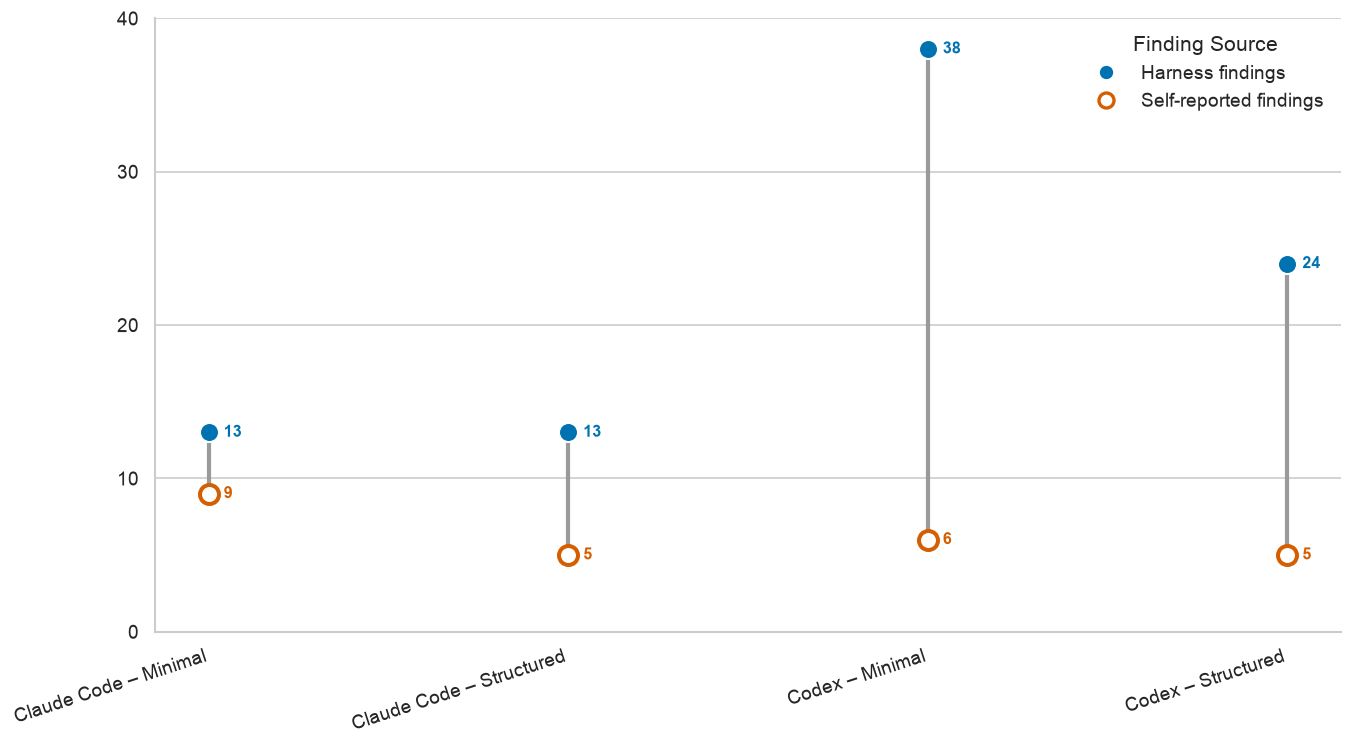

Saved PNG: figures/chapter4/harness_vs_agent_self_assessment.png
Saved PDF: figures/chapter4/harness_vs_agent_self_assessment.pdf
Saved SVG: figures/chapter4/harness_vs_agent_self_assessment.svg


In [39]:
from matplotlib.lines import Line2D

fig, ax_dot = plt.subplots(figsize=(11.5, 6.4))

x_positions = range(len(CONDITION_ORDER))
harness_color = "#0072B2"
self_report_color = "#D55E00"
for x, row in zip(x_positions, self_assessment.itertuples()):
    harness_count = int(row.absolute_finding_count)
    self_count = int(row.self_reported_finding_count)
    ax_dot.plot(
        [x, x], [self_count, harness_count],
        color="#9a9a9a", linewidth=2.5, solid_capstyle="round", zorder=1,
    )
    ax_dot.scatter(
        x, harness_count, s=130, color=harness_color,
        edgecolor="white", linewidth=1.2, zorder=3,
    )
    ax_dot.scatter(
        x, self_count, s=130, facecolor="white",
        edgecolor=self_report_color, linewidth=2.4, zorder=3,
    )
    ax_dot.annotate(
        str(harness_count), (x, harness_count), xytext=(9, 0),
        textcoords="offset points", ha="left", va="center",
        fontsize=9.5, color=harness_color, fontweight="bold",
    )
    ax_dot.annotate(
        str(self_count), (x, self_count), xytext=(9, 0),
        textcoords="offset points", ha="left", va="center",
        fontsize=9.5, color=self_report_color, fontweight="bold",
    )

legend_handles = [
    Line2D([0], [0], marker="o", linestyle="none", markersize=9,
           markerfacecolor=harness_color, markeredgecolor="white", label="Harness findings"),
    Line2D([0], [0], marker="o", linestyle="none", markersize=9,
           markerfacecolor="white", markeredgecolor=self_report_color, markeredgewidth=2,
           label="Self-reported findings"),
]
ax_dot.legend(handles=legend_handles, title="Finding Source", loc="upper right")
ax_dot.set_xticks(list(x_positions), CONDITION_ORDER, rotation=18, ha="right")
ax_dot.set_xlabel("")
ax_dot.set_ylim(0, 40)
ax_dot.set_yticks([0, 10, 20, 30, 40])
ax_dot.grid(axis="x", visible=False)
sns.despine(ax=ax_dot)

fig.tight_layout()
assert len(fig.axes) == 1, "Figure 6 must contain only the paired dot plot."

self_assessment_png_path = FIGURE_DIR / "harness_vs_agent_self_assessment.png"
self_assessment_pdf_path = FIGURE_DIR / "harness_vs_agent_self_assessment.pdf"
self_assessment_svg_path = FIGURE_DIR / "harness_vs_agent_self_assessment.svg"
fig.savefig(self_assessment_png_path, bbox_inches="tight")
fig.savefig(self_assessment_pdf_path, bbox_inches="tight")
fig.savefig(self_assessment_svg_path, format="svg", bbox_inches="tight")
plt.show()

print(f"Saved PNG: {self_assessment_png_path.relative_to(ANALYSIS_DIR)}")
print(f"Saved PDF: {self_assessment_pdf_path.relative_to(ANALYSIS_DIR)}")
print(f"Saved SVG: {self_assessment_svg_path.relative_to(ANALYSIS_DIR)}")

### Self-Assessment Calibration Summary

This is a standalone notebook table, not part of Figure 6. The three reported diagnostics retain their own count and percentage scales.

In [40]:
assert len(self_assessment_summary_table) == 4
self_assessment_table_style = (
    self_assessment_summary_table.style
    .hide(axis="index")
    .set_properties(**{"text-align": "center", "white-space": "nowrap"})
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#D9EAF7"),
                ("font-weight", "bold"),
                ("text-align", "center"),
            ],
        },
        {
            "selector": "tbody tr:nth-child(even)",
            "props": [("background-color", "#F6F8FA")],
        },
        {
            "selector": "td",
            "props": [("padding", "6px 10px"), ("border", "1px solid white")],
        },
    ])
)
display(self_assessment_table_style)

Condition,Coverage,"Under-reporting (n, %)",Location Agreement
Claude Code – Minimal,69.2%,4 (30.8%),22.2%
Claude Code – Structured,38.5%,8 (61.5%),20.0%
Codex – Minimal,15.8%,32 (84.2%),83.3%
Codex – Structured,20.8%,19 (79.2%),80.0%


### Figure audit

Harness findings use Dataset E's T3 Absolute Finding Count. Self-reported findings use the corresponding T4 review. Figure 6 contains one plot axis and no embedded table. Coverage and location agreement are shown in the standalone notebook table above; under-reporting percentage is exactly `1 − coverage` because every condition reports fewer findings than the Harness.

In [41]:
self_assessment_figure_audit = pd.DataFrame({
    "check": [
        "Dataset E conditions",
        "Harness checkpoint",
        "Review checkpoint",
        "Count pairs",
        "Figure axes (plot only)",
        "Standalone summary table rows",
        "Coverage recomputation matches Dataset E",
        "All conditions under-report",
        "PNG exists",
        "PDF exists",
    ],
    "result": [
        len(self_assessment),
        "T3",
        "T4",
        len(self_assessment),
        len(fig.axes),
        len(self_assessment_summary_table),
        (recomputed_coverage - self_assessment["self_report_coverage"]).abs().lt(1e-12).all(),
        self_assessment["under_reporting_count"].gt(0).all(),
        self_assessment_png_path.exists(),
        self_assessment_pdf_path.exists(),
    ],
})
display(self_assessment_figure_audit)
print("Figure 6 generated and validated successfully.")

,check,result
0,Dataset E conditions,4
1,Harness checkpoint,T3
2,Review checkpoint,T4
3,Count pairs,4
4,Figure axes (plot only),1
5,Standalone summary table rows,4
6,Coverage recomputation matches Dataset E,True
7,All conditions under-report,True
8,PNG exists,True
9,PDF exists,True


Figure 6 generated and validated successfully.
